<a href="https://colab.research.google.com/github/basualdoimportante-boop/proyecto2-analisis-datos/blob/main/EDA_dataset1_propiedades.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# CELDA 1 — Autenticación con Kaggle y Descarga del Dataset
# ============================================================

import os
import kagglehub

# Credenciales de API Heredadas (Legacy API Credentials)
# Estas son las credenciales clásicas que kagglehub reconoce correctamente
os.environ['KAGGLE_USERNAME'] = 'basualdoimportante'
os.environ['KAGGLE_KEY'] = '23be7bb105d2e86189a0111926cb3fe3'

# Descarga del dataset de precios de propiedades
# House Prices - Advanced Regression Techniques (Técnicas Avanzadas de Regresión para Precios de Casas)
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print(f"Dataset descargado en: {path}")


100%|██████████| 199k/199k [00:00<00:00, 485kB/s]

Extracting files...
Dataset descargado en: /root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques


Se usa herramienta de mejor manera , al hacer la conexion entre colab con keaggle para seguir entreenando modelos y sacar el maximo provecho

In [5]:
# ============================================================
# CELDA 2 — Carga del Dataset e Inspección Inicial
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el archivo de entrenamiento (Training File)
# Este archivo contiene las variables predictoras y el precio de venta
ruta = '/root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques'
df = pd.read_csv(f'{ruta}/train.csv')

print("=== FORMA DEL DATASET (Shape) ===")
print(f"Filas (Rows): {df.shape[0]} | Columnas (Columns): {df.shape[1]}")

print("\n=== PRIMERAS 5 FILAS (Head) ===")
print(df.head())

print("\n=== TIPOS DE DATOS (Data Types) ===")
print(df.dtypes.value_counts())

print("\n=== ESTADÍSTICAS DESCRIPTIVAS (Descriptive Statistics) ===")
print(df.describe())


=== FORMA DEL DATASET (Shape) ===
Filas (Rows): 1460 | Columnas (Columns): 81

=== PRIMERAS 5 FILAS (Head) ===
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0  

In [6]:
# ============================================================
# CELDA 3 — Análisis de Valores Nulos (Null Values)
# ============================================================

# Valores nulos (Null Values): celdas vacías sin información
# Son un desafío común en datasets reales
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
porcentaje_nulos = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
})

print("=== COLUMNAS CON VALORES NULOS (Null Values) ===")
print(resumen_nulos)
print(f"\nTotal de columnas con nulos: {len(nulos)}")

=== COLUMNAS CON VALORES NULOS (Null Values) ===
              Valores Nulos  Porcentaje (%)
PoolQC                 1453           99.52
MiscFeature            1406           96.30
Alley                  1369           93.77
Fence                  1179           80.75
MasVnrType              872           59.73
FireplaceQu             690           47.26
LotFrontage             259           17.74
GarageType               81            5.55
GarageYrBlt              81            5.55
GarageFinish             81            5.55
GarageQual               81            5.55
GarageCond               81            5.55
BsmtExposure             38            2.60
BsmtFinType2             38            2.60
BsmtQual                 37            2.53
BsmtCond                 37            2.53
BsmtFinType1             37            2.53
MasVnrArea                8            0.55
Electrical                1            0.07

Total de columnas con nulos: 19


In [7]:
# ============================================================
# CELDA 4 — Traducción de Columnas y Valores Categóricos
# ============================================================

# Diccionario de traducción de columnas (Column Translation Dictionary)
traduccion_columnas = {
    'Id': 'ID',
    'MSSubClass': 'Clase_Edificio',
    'MSZoning': 'Zonificacion',
    'LotFrontage': 'Frente_Terreno_m2',
    'LotArea': 'Area_Terreno_m2',
    'Street': 'Tipo_Calle',
    'Alley': 'Tipo_Callejon',
    'LotShape': 'Forma_Terreno',
    'LandContour': 'Contorno_Terreno',
    'Utilities': 'Servicios_Basicos',
    'LotConfig': 'Configuracion_Terreno',
    'LandSlope': 'Pendiente_Terreno',
    'Neighborhood': 'Barrio',
    'Condition1': 'Condicion_Proximidad_1',
    'Condition2': 'Condicion_Proximidad_2',
    'BldgType': 'Tipo_Edificio',
    'HouseStyle': 'Estilo_Casa',
    'OverallQual': 'Calidad_General',
    'OverallCond': 'Condicion_General',
    'YearBuilt': 'Anio_Construccion',
    'YearRemodAdd': 'Anio_Remodelacion',
    'RoofStyle': 'Estilo_Techo',
    'RoofMatl': 'Material_Techo',
    'Exterior1st': 'Revestimiento_Exterior_1',
    'Exterior2nd': 'Revestimiento_Exterior_2',
    'MasVnrType': 'Tipo_Revestimiento_Piedra',
    'MasVnrArea': 'Area_Revestimiento_Piedra',
    'ExterQual': 'Calidad_Exterior',
    'ExterCond': 'Condicion_Exterior',
    'Foundation': 'Tipo_Cimiento',
    'BsmtQual': 'Calidad_Sotano',
    'BsmtCond': 'Condicion_Sotano',
    'BsmtExposure': 'Exposicion_Sotano',
    'BsmtFinType1': 'Tipo_Terminacion_Sotano_1',
    'BsmtFinSF1': 'Superficie_Terminada_Sotano_1',
    'BsmtFinType2': 'Tipo_Terminacion_Sotano_2',
    'BsmtFinSF2': 'Superficie_Terminada_Sotano_2',
    'BsmtUnfSF': 'Superficie_Sin_Terminar_Sotano',
    'TotalBsmtSF': 'Superficie_Total_Sotano',
    'Heating': 'Tipo_Calefaccion',
    'HeatingQC': 'Calidad_Calefaccion',
    'CentralAir': 'Aire_Acondicionado_Central',
    'Electrical': 'Sistema_Electrico',
    'X1stFlrSF': 'Superficie_Primer_Piso',
    '1stFlrSF': 'Superficie_Primer_Piso',
    '2ndFlrSF': 'Superficie_Segundo_Piso',
    'LowQualFinSF': 'Superficie_Baja_Calidad',
    'GrLivArea': 'Superficie_Habitable',
    'BsmtFullBath': 'Banos_Completos_Sotano',
    'BsmtHalfBath': 'Medios_Banos_Sotano',
    'FullBath': 'Banos_Completos',
    'HalfBath': 'Medios_Banos',
    'BedroomAbvGr': 'Dormitorios',
    'KitchenAbvGr': 'Cocinas',
    'KitchenQual': 'Calidad_Cocina',
    'TotRmsAbvGrd': 'Total_Habitaciones',
    'Functional': 'Funcionalidad_Casa',
    'Fireplaces': 'Cantidad_Chimeneas',
    'FireplaceQu': 'Calidad_Chimenea',
    'GarageType': 'Tipo_Garage',
    'GarageYrBlt': 'Anio_Construccion_Garage',
    'GarageFinish': 'Terminacion_Garage',
    'GarageCars': 'Capacidad_Garage_Autos',
    'GarageArea': 'Superficie_Garage',
    'GarageQual': 'Calidad_Garage',
    'GarageCond': 'Condicion_Garage',
    'PavedDrive': 'Entrada_Pavimentada',
    'WoodDeckSF': 'Superficie_Deck_Madera',
    'OpenPorchSF': 'Superficie_Porche_Abierto',
    'EnclosedPorch': 'Superficie_Porche_Cerrado',
    '3SsnPorch': 'Superficie_Porche_3_Estaciones',
    'ScreenPorch': 'Superficie_Porche_Malla',
    'PoolArea': 'Superficie_Piscina',
    'PoolQC': 'Calidad_Piscina',
    'Fence': 'Calidad_Cerca',
    'MiscFeature': 'Caracteristica_Adicional',
    'MiscVal': 'Valor_Caracteristica_Adicional',
    'MoSold': 'Mes_Venta',
    'YrSold': 'Anio_Venta',
    'SaleType': 'Tipo_Venta',
    'SaleCondition': 'Condicion_Venta',
    'SalePrice': 'Precio_Venta'
}

# Renombramos las columnas del DataFrame
df.rename(columns=traduccion_columnas, inplace=True)

print("=== COLUMNAS TRADUCIDAS AL ESPAÑOL ===")
print(df.columns.tolist())
print(f"\nTotal de columnas: {df.shape[1]}")

=== COLUMNAS TRADUCIDAS AL ESPAÑOL ===
['ID', 'Clase_Edificio', 'Zonificacion', 'Frente_Terreno_m2', 'Area_Terreno_m2', 'Tipo_Calle', 'Tipo_Callejon', 'Forma_Terreno', 'Contorno_Terreno', 'Servicios_Basicos', 'Configuracion_Terreno', 'Pendiente_Terreno', 'Barrio', 'Condicion_Proximidad_1', 'Condicion_Proximidad_2', 'Tipo_Edificio', 'Estilo_Casa', 'Calidad_General', 'Condicion_General', 'Anio_Construccion', 'Anio_Remodelacion', 'Estilo_Techo', 'Material_Techo', 'Revestimiento_Exterior_1', 'Revestimiento_Exterior_2', 'Tipo_Revestimiento_Piedra', 'Area_Revestimiento_Piedra', 'Calidad_Exterior', 'Condicion_Exterior', 'Tipo_Cimiento', 'Calidad_Sotano', 'Condicion_Sotano', 'Exposicion_Sotano', 'Tipo_Terminacion_Sotano_1', 'Superficie_Terminada_Sotano_1', 'Tipo_Terminacion_Sotano_2', 'Superficie_Terminada_Sotano_2', 'Superficie_Sin_Terminar_Sotano', 'Superficie_Total_Sotano', 'Tipo_Calefaccion', 'Calidad_Calefaccion', 'Aire_Acondicionado_Central', 'Sistema_Electrico', 'Superficie_Primer_Piso'

In [8]:
# ============================================================
# CELDA 5 — Traducción de Valores Categóricos
# ============================================================

# Calidad general (escala 1-10) — ya es numérica, no necesita traducción

# Zonificacion (Zoning)
df['Zonificacion'] = df['Zonificacion'].replace({
    'A': 'Agricola',
    'C': 'Comercial',
    'FV': 'Residencial_Flotante',
    'I': 'Industrial',
    'RH': 'Residencial_Alta_Densidad',
    'RL': 'Residencial_Baja_Densidad',
    'RP': 'Residencial_Baja_Densidad_Parque',
    'RM': 'Residencial_Media_Densidad'
})

# Tipo de calle (Street Type)
df['Tipo_Calle'] = df['Tipo_Calle'].replace({
    'Grvl': 'Grava',
    'Pave': 'Pavimentada'
})

# Tipo de callejón (Alley Type)
df['Tipo_Callejon'] = df['Tipo_Callejon'].replace({
    'Grvl': 'Grava',
    'Pave': 'Pavimentado'
})

# Forma del terreno (Lot Shape)
df['Forma_Terreno'] = df['Forma_Terreno'].replace({
    'Reg': 'Regular',
    'IR1': 'Irregular_Leve',
    'IR2': 'Irregular_Moderado',
    'IR3': 'Irregular_Severo'
})

# Calidad y condición general (Quality/Condition scale)
escala_calidad = {'Ex': 'Excelente', 'Gd': 'Buena', 'TA': 'Promedio', 'Fa': 'Regular', 'Po': 'Mala'}

for col in ['Calidad_Exterior', 'Condicion_Exterior', 'Calidad_Sotano',
            'Condicion_Sotano', 'Calidad_Calefaccion', 'Calidad_Cocina',
            'Calidad_Garage', 'Condicion_Garage', 'Calidad_Chimenea', 'Calidad_Piscina']:
    df[col] = df[col].replace(escala_calidad)

# Aire acondicionado central (Central Air Conditioning)
df['Aire_Acondicionado_Central'] = df['Aire_Acondicionado_Central'].replace({
    'Y': 'Si',
    'N': 'No'
})

# Tipo de edificio (Building Type)
df['Tipo_Edificio'] = df['Tipo_Edificio'].replace({
    '1Fam': 'Unifamiliar',
    '2FmCon': 'Bifamiliar_Convertido',
    'Duplx': 'Duplex',
    'TwnhsE': 'Townhouse_Esquina',
    'TwnhsI': 'Townhouse_Interior'
})

# Condición de venta (Sale Condition)
df['Condicion_Venta'] = df['Condicion_Venta'].replace({
    'Normal': 'Normal',
    'Abnorml': 'Anormal',
    'AdjLand': 'Terreno_Adyacente',
    'Alloca': 'Asignacion',
    'Family': 'Familiar',
    'Partial': 'Parcial'
})

# Tipo de venta (Sale Type)
df['Tipo_Venta'] = df['Tipo_Venta'].replace({
    'WD': 'Escritura_Normal',
    'CWD': 'Escritura_Con_Garantia',
    'VWD': 'Escritura_Con_Garantia_Vendedor',
    'New': 'Casa_Nueva',
    'COD': 'Orden_Judicial',
    'Con': 'Contrato',
    'ConLw': 'Contrato_Bajo_Interes',
    'ConLI': 'Contrato_Bajo_Enganche',
    'ConLD': 'Contrato_Bajo_Enganche_Interes',
    'Oth': 'Otro'
})

# Entrada pavimentada (Paved Drive)
df['Entrada_Pavimentada'] = df['Entrada_Pavimentada'].replace({
    'Y': 'Pavimentada',
    'P': 'Parcialmente_Pavimentada',
    'N': 'Sin_Pavimentar'
})

print("=== VALORES CATEGÓRICOS TRADUCIDOS ===")
print("\nZonificacion:", df['Zonificacion'].unique())
print("Tipo_Calle:", df['Tipo_Calle'].unique())
print("Tipo_Edificio:", df['Tipo_Edificio'].unique())
print("Condicion_Venta:", df['Condicion_Venta'].unique())
print("Aire_Acondicionado_Central:", df['Aire_Acondicionado_Central'].unique())
print("\n✓ Traducción completada exitosamente")

=== VALORES CATEGÓRICOS TRADUCIDOS ===

Zonificacion: ['Residencial_Baja_Densidad' 'Residencial_Media_Densidad' 'C (all)'
 'Residencial_Flotante' 'Residencial_Alta_Densidad']
Tipo_Calle: ['Pavimentada' 'Grava']
Tipo_Edificio: ['Unifamiliar' '2fmCon' 'Duplex' 'Townhouse_Esquina' 'Twnhs']
Condicion_Venta: ['Normal' 'Anormal' 'Parcial' 'Terreno_Adyacente' 'Asignacion' 'Familiar']
Aire_Acondicionado_Central: ['Si' 'No']

✓ Traducción completada exitosamente


In [9]:
# ============================================================
# CELDA 6 — Corrección de Valores Categóricos No Traducidos
# ============================================================

# Corregimos los valores que no coincidieron por diferencias de escritura
df['Zonificacion'] = df['Zonificacion'].replace({
    'C (all)': 'Comercial'
})

df['Tipo_Edificio'] = df['Tipo_Edificio'].replace({
    '2fmCon': 'Bifamiliar_Convertido',
    'Twnhs': 'Townhouse_Interior'
})

print("Zonificacion:", df['Zonificacion'].unique())
print("Tipo_Edificio:", df['Tipo_Edificio'].unique())
print("\n✓ Correcciones aplicadas exitosamente")

Zonificacion: ['Residencial_Baja_Densidad' 'Residencial_Media_Densidad' 'Comercial'
 'Residencial_Flotante' 'Residencial_Alta_Densidad']
Tipo_Edificio: ['Unifamiliar' 'Bifamiliar_Convertido' 'Duplex' 'Townhouse_Esquina'
 'Townhouse_Interior']

✓ Correcciones aplicadas exitosamente


In [10]:
# ============================================================
# CELDA 7 — Revisión de Duplicados (Duplicate Values)
# ============================================================

# Duplicados: filas idénticas que representan el mismo registro dos veces
# En un dataset inmobiliario no debería haber propiedades idénticas
duplicados = df.duplicated().sum()

print("=== REVISIÓN DE DUPLICADOS ===")
print(f"Total de filas duplicadas: {duplicados}")

if duplicados == 0:
    print("✓ No se encontraron duplicados. El dataset está limpio en este aspecto.")
else:
    print(f"⚠ Se encontraron {duplicados} filas duplicadas. Se recomienda eliminarlas.")

=== REVISIÓN DE DUPLICADOS ===
Total de filas duplicadas: 0
✓ No se encontraron duplicados. El dataset está limpio en este aspecto.


In [11]:
# ============================================================
# CELDA 8 — Tipos de Datos (Data Types) y Resumen General
# ============================================================

# Data Types (Tipos de Datos): clasificación de cada columna
# int64 = números enteros (Números Enteros)
# float64 = números decimales (Números Decimales)
# object = texto o categorías (Texto o Categorías)

print("=== TIPOS DE DATOS POR COLUMNA ===")
print(df.dtypes)

print("\n=== RESUMEN GENERAL DEL DATASET ===")
print(f"Filas (Rows): {df.shape[0]}")
print(f"Columnas (Columns): {df.shape[1]}")
print(f"Columnas numéricas (Numeric Columns): {df.select_dtypes(include=['int64','float64']).shape[1]}")
print(f"Columnas categóricas (Categorical Columns): {df.select_dtypes(include=['object']).shape[1]}")
print(f"Columnas con valores nulos (Null Values): 19")
print(f"Duplicados (Duplicates): {df.duplicated().sum()}")
print(f"Precio de venta promedio (Average Sale Price): ${df['Precio_Venta'].mean():,.0f}")
print(f"Precio de venta mínimo (Minimum Sale Price): ${df['Precio_Venta'].min():,.0f}")
print(f"Precio de venta máximo (Maximum Sale Price): ${df['Precio_Venta'].max():,.0f}")

=== TIPOS DE DATOS POR COLUMNA ===
ID                     int64
Clase_Edificio         int64
Zonificacion          object
Frente_Terreno_m2    float64
Area_Terreno_m2        int64
                      ...   
Mes_Venta              int64
Anio_Venta             int64
Tipo_Venta            object
Condicion_Venta       object
Precio_Venta           int64
Length: 81, dtype: object

=== RESUMEN GENERAL DEL DATASET ===
Filas (Rows): 1460
Columnas (Columns): 81
Columnas numéricas (Numeric Columns): 38
Columnas categóricas (Categorical Columns): 43
Columnas con valores nulos (Null Values): 19
Duplicados (Duplicates): 0
Precio de venta promedio (Average Sale Price): $180,921
Precio de venta mínimo (Minimum Sale Price): $34,900
Precio de venta máximo (Maximum Sale Price): $755,000


## Descripción del Dataset y Contexto de Negocio

### Fuente
House Prices - Advanced Regression Techniques  
Kaggle: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

### Descripción General
Este dataset contiene información detallada de 1.460 propiedades residenciales
vendidas en Ames, Iowa, Estados Unidos, entre los años 2006 y 2010.
Incluye 81 variables que describen prácticamente cada aspecto de una propiedad:
características físicas, calidad de construcción, ubicación por barrio,
superficies por sector, equipamiento y condiciones de venta.

### Relevancia para el Análisis
El mercado inmobiliario es uno de los sectores donde el Machine Learning
(Aprendizaje Automático) tiene mayor impacto práctico. La capacidad de predecir
el precio de venta de una propiedad a partir de sus características permite a
empresas inmobiliarias, tasadores y entidades financieras tomar decisiones más
precisas, reduciendo el margen de error humano en la valorización de activos.

### Problemática Seleccionada
**Regresión (Regression):** predecir el precio de venta (Precio_Venta)
de una propiedad a partir de sus características físicas, de calidad y de ubicación. idea de negocio(?)

### Variable Objetivo
- **Precio_Venta:** precio final de venta de la propiedad en dólares estadounidenses.
  Rango observado: $34.900 — $755.000 | Promedio: $180.921
"""

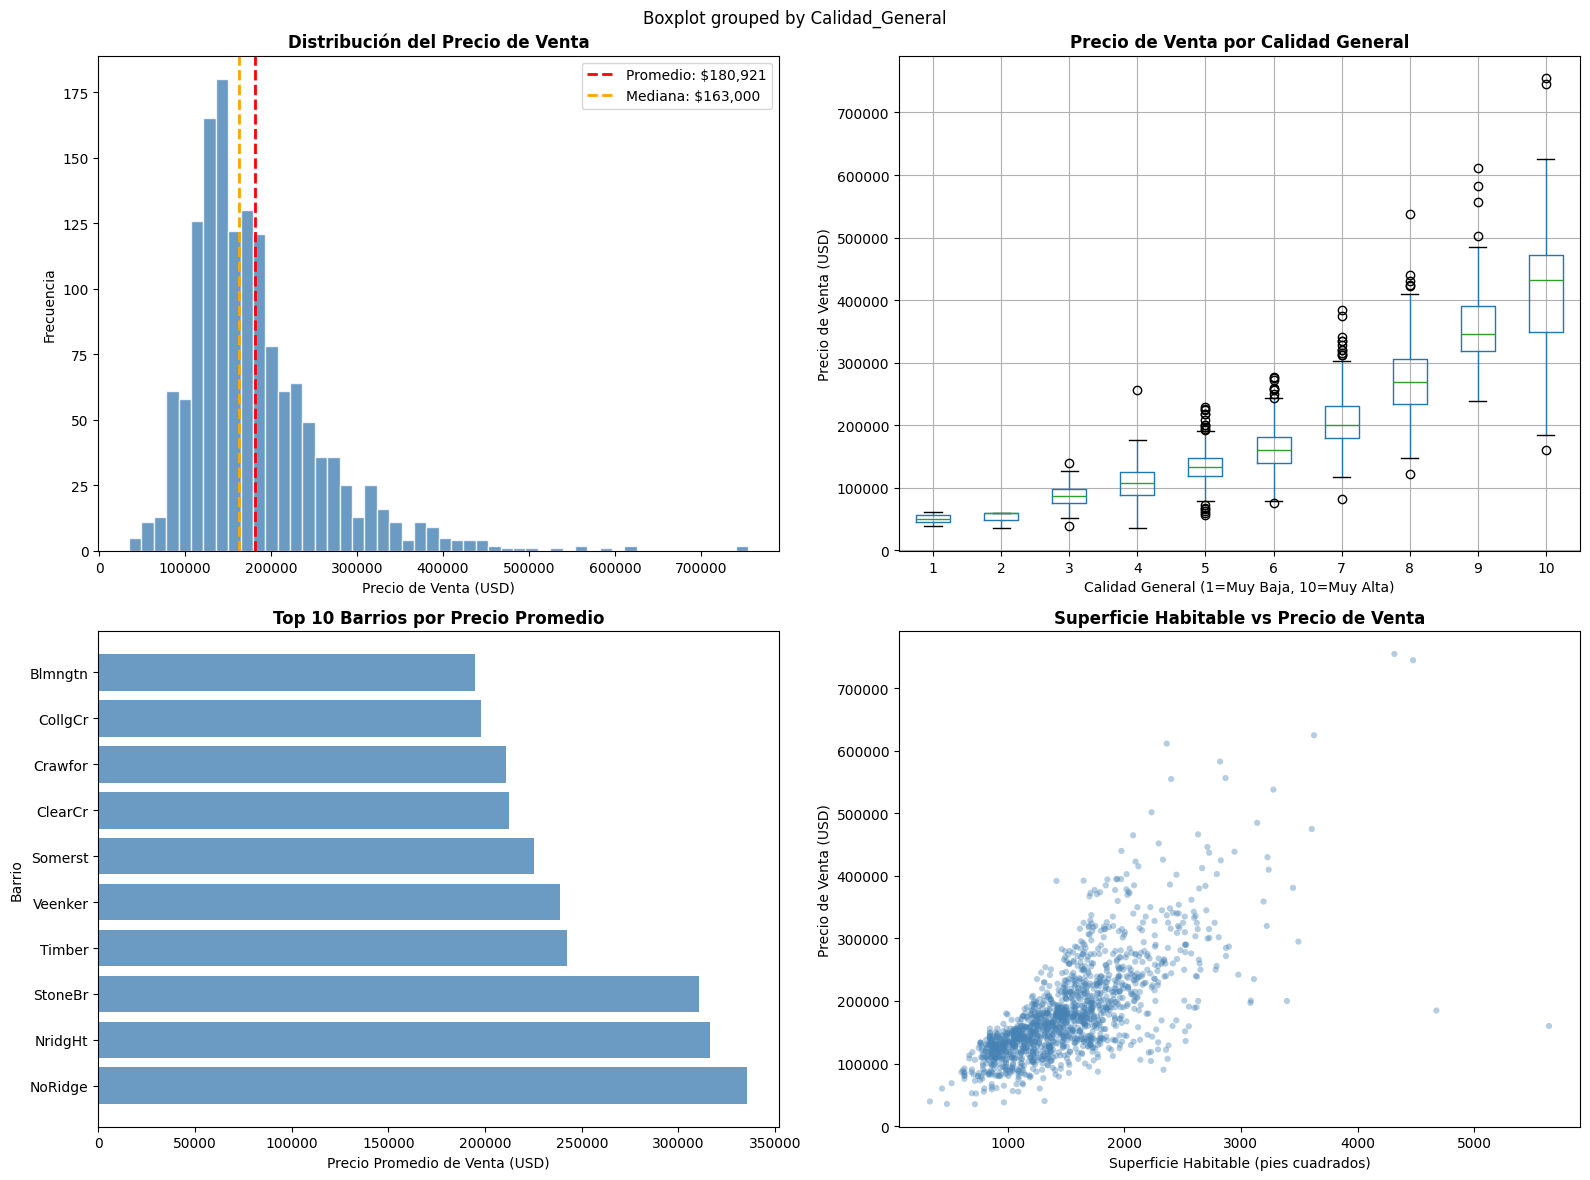

✓ Visualizaciones generadas exitosamente


In [13]:
# ============================================================
# CELDA 10 — Visualizaciones del EDA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Exploratorio de Datos — Dataset de Precios de Propiedades',
             fontsize=16, fontweight='bold', y=1.02)

# --- GRÁFICO 1: Distribución del Precio de Venta (Distribution Plot) ---
axes[0, 0].hist(df['Precio_Venta'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(df['Precio_Venta'].mean(), color='red', linestyle='--', linewidth=2, label=f'Promedio: ${df["Precio_Venta"].mean():,.0f}')
axes[0, 0].axvline(df['Precio_Venta'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: ${df["Precio_Venta"].median():,.0f}')
axes[0, 0].set_title('Distribución del Precio de Venta', fontweight='bold')
axes[0, 0].set_xlabel('Precio de Venta (USD)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# --- GRÁFICO 2: Precio de Venta por Calidad General (Box Plot) ---
calidad_orden = sorted(df['Calidad_General'].unique())
df.boxplot(column='Precio_Venta', by='Calidad_General', ax=axes[0, 1],
           positions=calidad_orden)
axes[0, 1].set_title('Precio de Venta por Calidad General', fontweight='bold')
axes[0, 1].set_xlabel('Calidad General (1=Muy Baja, 10=Muy Alta)')
axes[0, 1].set_ylabel('Precio de Venta (USD)')
plt.sca(axes[0, 1])
plt.title('Precio de Venta por Calidad General', fontweight='bold')

# --- GRÁFICO 3: Top 10 Barrios por Precio Promedio (Bar Plot) ---
top_barrios = df.groupby('Barrio')['Precio_Venta'].mean().sort_values(ascending=False).head(10)
axes[1, 0].barh(top_barrios.index, top_barrios.values, color='steelblue', alpha=0.8)
axes[1, 0].set_title('Top 10 Barrios por Precio Promedio', fontweight='bold')
axes[1, 0].set_xlabel('Precio Promedio de Venta (USD)')
axes[1, 0].set_ylabel('Barrio')

# --- GRÁFICO 4: Correlación Superficie Habitable vs Precio (Scatter Plot) ---
axes[1, 1].scatter(df['Superficie_Habitable'], df['Precio_Venta'],
                   alpha=0.4, color='steelblue', edgecolors='none', s=20)
axes[1, 1].set_title('Superficie Habitable vs Precio de Venta', fontweight='bold')
axes[1, 1].set_xlabel('Superficie Habitable (pies cuadrados)')
axes[1, 1].set_ylabel('Precio de Venta (USD)')

plt.tight_layout()
plt.savefig('visualizaciones_eda_propiedades.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualizaciones generadas exitosamente")


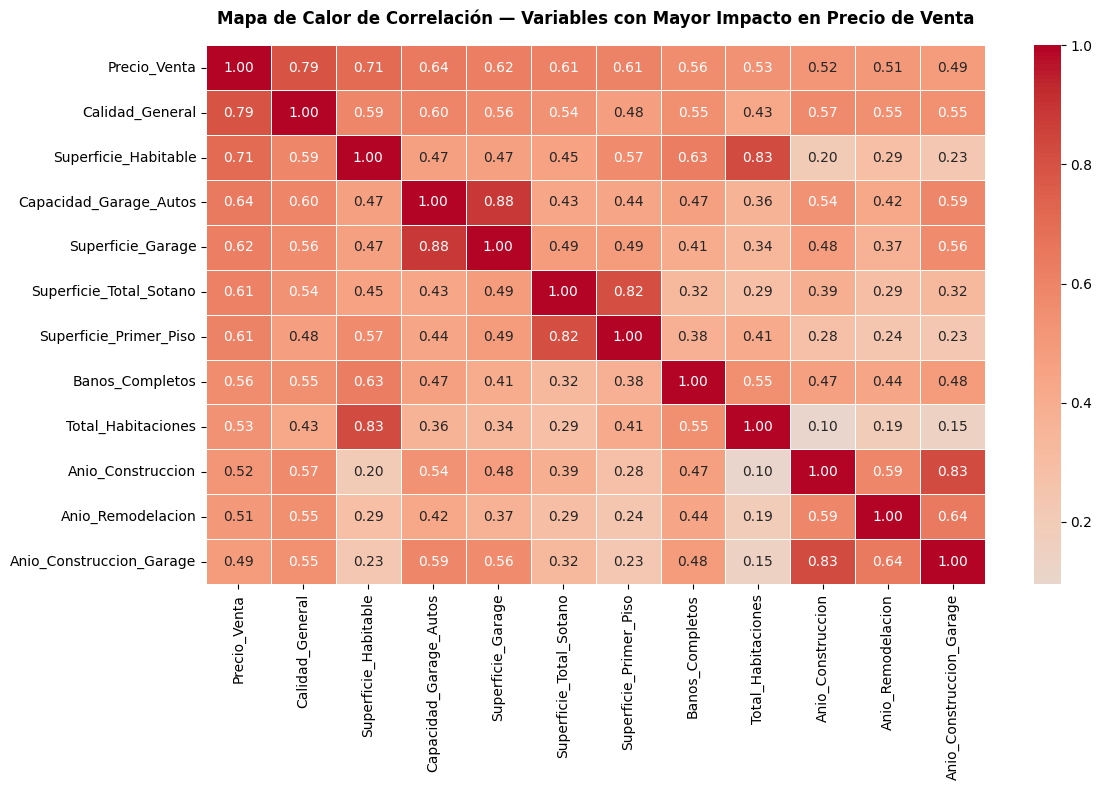

✓ Mapa de correlación generado exitosamente


In [14]:
# ============================================================
# CELDA 11 — Mapa de Calor de Correlación (Correlation Heatmap)
# ============================================================

# Correlation (Correlación): medida estadística que indica qué tan relacionadas
# están dos variables. Va de -1 (correlación negativa perfecta) a 1 (positiva perfecta)

# Seleccionamos las 12 variables numéricas con mayor correlación con el precio
correlaciones = df.select_dtypes(include=['int64', 'float64']).corr()
top_correlaciones = correlaciones['Precio_Venta'].abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[top_correlaciones].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Mapa de Calor de Correlación — Variables con Mayor Impacto en Precio de Venta',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlacion_propiedades.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Mapa de correlación generado exitosamente")

### Descripción General del Dataset
El dataset contiene 1.460 registros de propiedades residenciales vendidas en
Ames, Iowa, Estados Unidos, entre 2006 y 2010. Cuenta con 81 variables que
describen características físicas, de calidad, ubicación y condiciones de venta.
No se encontraron filas duplicadas, lo que indica un dataset confiable
### Hallazgos Principales

**1. Variables con mayor impacto en el Precio de Venta**
El análisis de correlación (Correlation Analysis) reveló, como era de esperar, que las variables con
mayor influencia sobre el precio de venta son la Calidad General (0.79),
la Superficie Habitable (0.71) y la Capacidad del Garage (0.64) recoradr que EEUU es un pais altamente consumidor de vehiculos particulares. Esto indica
que un comprador valora principalmente la calidad de construcción y el tamaño
útil de la propiedad por encima de otros factores.

**2. Multicolinealidad detectada**
Se identificaron pares de variables con alta correlación entre sí, como
Capacidad_Garage_Autos y Superficie_Garage (0.88), y Total_Habitaciones
y Superficie_Habitable (0.83). Esto se denomina Multicolinealidad
(Multicollinearity) y deberá considerarse en la etapa de modelado para
evitar REDUNDANCIA en las variables predictoras.

**3. Valores nulos con lógica de negocio**
El dataset presenta 19 columnas con valores nulos. Las columnas Calidad_Piscina
(99.52%), Caracteristica_Adicional (96.30%) y Tipo_Callejon (93.77%) tienen
nulos que no representan errores sino ausencia real del atributo: la mayoría
de las propiedades simplemente no tienen piscina, callejón ni característica
adicional. Estas columnas serán tratadas reemplazando los nulos por la
categoría "No_Aplica" en la etapa de preprocesamiento.

**4. Distribución del Precio de Venta**
El precio de venta presenta una distribución asimétrica hacia la derecha
(Right-Skewed Distribution), con un promedio de $180.921 y una mediana de
$163.000. La diferencia entre ambos indica la presencia de propiedades de
alto valor que elevan el promedio. El rango va desde $34.900 hasta $755.000.

**5. Impacto del barrio en el precio**
El análisis por barrio reveló diferencias significativas en el precio promedio
de venta. Los barrios de mayor valor superan ampliamente el promedio general,
lo que confirma que la ubicación es un factor determinante en la valorización
inmobiliaria, consistente con la teoría clásica del mercado de bienes raíces.

**6. Limitaciones identificadas y análisis adicional propuesto**
Aunque el dataset no permite calcular directamente la probabilidad de venta
ni el tiempo en mercado (ya que todas las propiedades registradas fueron
efectivamente vendidas y no se dispone de fecha de publicación), las variables
Mes_Venta y Anio_Venta permiten analizar estacionalidad (Seasonality) en las
transacciones. Este análisis podría revelar en qué meses se concentran más
ventas y si el precio varía según la época del año, información de alto valor
para una empresa inmobiliaria.

### Problemática Seleccionada
Se selecciona una problemática de Regresión (Regression): predecir el
Precio_Venta de una propiedad a partir de sus características físicas,
de calidad y de ubicación. Esta problemática es relevante para el sector
inmobiliario porque permite automatizar la valorización de propiedades,
reducir el margen de error humano en tasaciones y apoyar decisiones de
inversión con respaldo cuantitativo.